## **Importing Libraries**

In [240]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import requests
import warnings
import scipy.stats as stats
from scipy.stats import shapiro, normaltest,zscore
warnings.filterwarnings('ignore')

In [241]:
btc_historical_df=pd.read_csv(r"C:\Users\yhsai\bitcoin-forecasting-with-facebook-prophet\data.csv\bitcoin_prices_historical.csv")
btc_historical_df.head()

,Timestamp,Open,High,Low,Close,Volume,datetime
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:01:00+00:00
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:02:00+00:00
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:03:00+00:00
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:04:00+00:00
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:05:00+00:00


In [242]:
# Convert Timestamp to datetime
btc_historical_df['datetime'] = pd.to_datetime(btc_historical_df['Timestamp'], unit='s')
# Keep only necessary columns
btc_historical_df = btc_historical_df[['datetime', 'Close']].dropna()
# Rename columns for Prophet
btc_historical_df.rename(columns={'datetime': 'ds', 'Close': 'y'}, inplace=True)

In [243]:
# Assume df has columns: ds (datetime), y (price)
btc_historical_df = btc_historical_df.set_index('ds').resample('D').agg({'y': 'last'}).reset_index()

In [244]:
btc_historical_df.head()

,ds,y
0,2012-01-01,4.84
1,2012-01-02,5.00
2,2012-01-03,5.29
3,2012-01-04,5.57
4,2012-01-05,6.42


### **Steps done so far**

#### Data Preparation and Cleaning

1. **Loaded Bitcoin Historical Price Data**
   - Format: Minute-level OHLCV data from 2012 to 2025
   - Purpose: Provides long-term historical price data ideal for time series forecasting.


2. **Converted UNIX Timestamps to Datetime**
   - Converted the Timestamp column to datetime format
   - Renamed the datetime column to ds to match Prophet's required input format
     

3. **Renamed the Close Column to y**
   - Prophet requires two specific column names:
     - ds for the datetime
     - y for the target value (price)
   - We used the Close price as y, which reflects the final traded price for each minute
     

4. **Resampled the Data to Daily Frequency**
   - Used .resample('D').last() to select the **last traded price of each day** (daily close)
   - This is the most realistic way to represent daily prices in financial time series
   - Resulted in a clean dataset with one row per day and two columns: `ds` and `y`

---
#### Why This Approach?
- Facebook Prophet is optimized for **daily-level data** with clear trends and seasonality.
- Resampling avoids noise from high-frequency data and improves model stability.
- Using the daily close price ensures realistic and explainable forecasting outputs.

In [245]:
# Fetch Live Data from CoinGecko API
def fetch_coingecko_prices():
    url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"
    params = {
        'vs_currency': 'usd',
        'days': '365',
        'interval': 'daily'
    }
    response = requests.get(url, params=params)
    data = response.json()
    prices = data['prices']

    df = pd.DataFrame(prices, columns=['timestamp', 'y'])
    df['ds'] = pd.to_datetime(df['timestamp'], unit='ms')
    return df[['ds', 'y']]

In [246]:
btc_live_df=fetch_coingecko_prices()

In [247]:
btc_live_df.head()

,ds,y
0,2024-04-07,69000.649916
1,2024-04-08,69401.973609
2,2024-04-09,71624.184862
3,2024-04-10,69158.643812
4,2024-04-11,70527.889976


In [248]:
btc_final_df=pd.concat([btc_historical_df,btc_live_df])
btc_final_df.head()

,ds,y
0,2012-01-01,4.84
1,2012-01-02,5.00
2,2012-01-03,5.29
3,2012-01-04,5.57
4,2012-01-05,6.42


In [249]:
btc_final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5191 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      5191 non-null   datetime64[ns]
 1   y       5191 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 121.7 KB


In [250]:
#checking number of duplicates
print('Number of duplicate dates:',btc_final_df['ds'].duplicated().sum())

Number of duplicate dates: 345


In [251]:
btc_final_df.drop_duplicates(subset='ds', keep='last', inplace=True)
btc_final_df.head()

,ds,y
0,2012-01-01,4.84
1,2012-01-02,5.00
2,2012-01-03,5.29
3,2012-01-04,5.57
4,2012-01-05,6.42


In [252]:
btc_final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4846 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      4846 non-null   datetime64[ns]
 1   y       4846 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 113.6 KB


In [253]:
btc_final_df.sort_values('ds',inplace=True)

In [254]:
btc_final_df

,ds,y
0,2012-01-01 00:00:00,4.840000
1,2012-01-02 00:00:00,5.000000
2,2012-01-03 00:00:00,5.290000
3,2012-01-04 00:00:00,5.570000
4,2012-01-05 00:00:00,6.420000
...,...,...
361,2025-04-03 00:00:00,82526.422153
362,2025-04-04 00:00:00,83163.987574
363,2025-04-05 00:00:00,83852.007654
364,2025-04-06 00:00:00,83595.885502


In [255]:
# Assume df has columns: ds (datetime), y (price)
btc_final_df = btc_final_df.set_index('ds').resample('D').agg({'y': 'last'}).reset_index()

In [256]:
btc_final_df

,ds,y
0,2012-01-01,4.840000
1,2012-01-02,5.000000
2,2012-01-03,5.290000
3,2012-01-04,5.570000
4,2012-01-05,6.420000
...,...,...
4840,2025-04-02,85237.587605
4841,2025-04-03,82526.422153
4842,2025-04-04,83163.987574
4843,2025-04-05,83852.007654


In [257]:
btc_final_df.shape

(4845, 2)

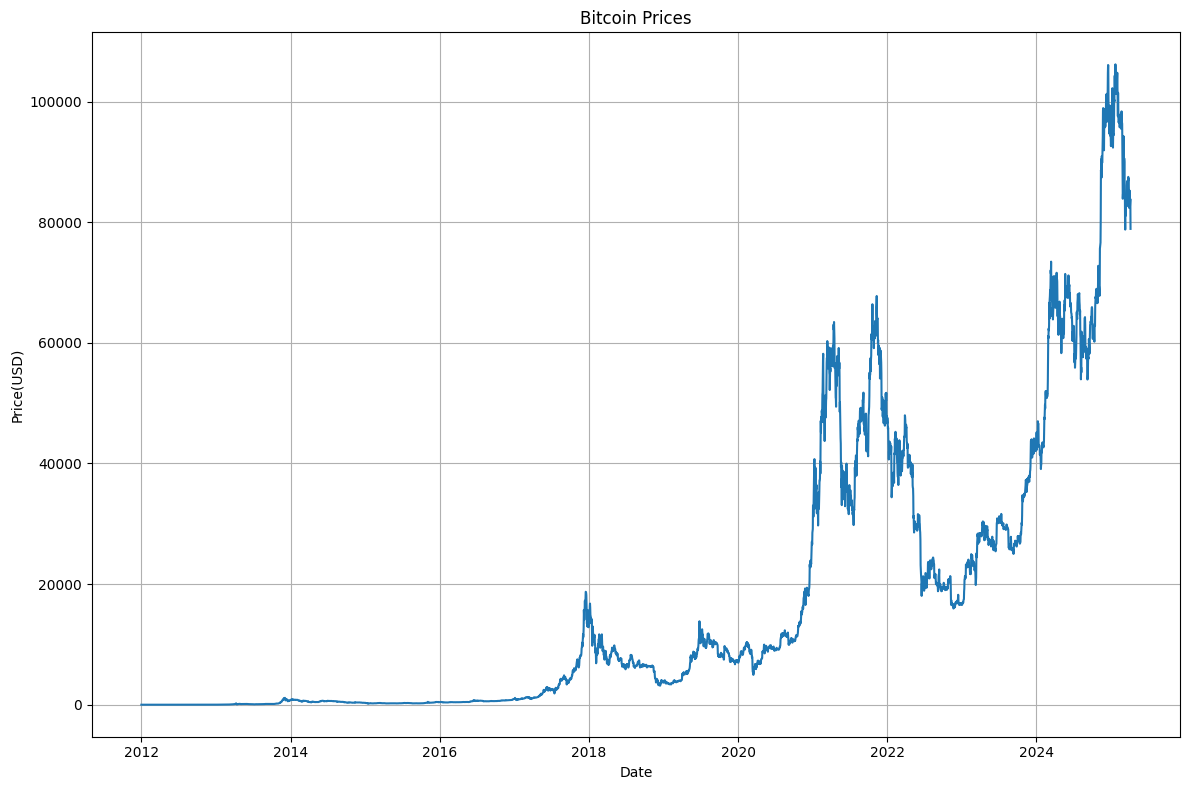

In [258]:
plt.figure(figsize=(12,8))
plt.plot(btc_final_df['ds'],btc_final_df['y'], label='BTC Prices')
plt.title('Bitcoin Prices')
plt.xlabel('Date')
plt.ylabel('Price(USD)')
plt.grid(True)
plt.legend
plt.tight_layout()
plt.show()

### **Bitcoin Price Trend (2012–2025) – Inference**

The plot shows a strong **long-term upward trend** in Bitcoin prices, rising from under 100 dollars in 2012 to over 100,000 dolars by 2024. The trend is marked by **extreme volatility**, with sharp rises and crashes occurring around 2017, 2021, and 2024 — suggesting **cyclical market behavior**. A recent pullback after the 2024 peak indicates a potential market correction. These patterns imply the presence of **trend, seasonality, and high variance**, all of which are critical factors to model accurately using Facebook Prophet.


## **Exploratory Data Analysis**

### Dataset Overview

In [259]:
# Time range
print("Start Date:", btc_final_df['ds'].min())
print("End Date:", btc_final_df['ds'].max())

Start Date: 2012-01-01 00:00:00
End Date: 2025-04-06 00:00:00


In [260]:
# Total records 
print("total Daily records:",len(btc_final_df))

total Daily records: 4845


In [261]:
#checking number of duplicates
print('Number of duplicate dates:',btc_final_df['ds'].duplicated().sum())

Number of duplicate dates: 0


In [262]:
print('Statistics Summary of our Dataset:')
btc_final_df.describe()

Statistics Summary of our Dataset:


,ds,y
count,4845,4845.000000
mean,2018-08-19 00:00:00,17058.027025
min,2012-01-01 00:00:00,4.380000
25%,2015-04-26 00:00:00,422.180000
50%,2018-08-19 00:00:00,6538.290000
75%,2021-12-12 00:00:00,26945.000000
max,2025-04-06 00:00:00,106182.236820
std,NaN,23601.720760


### Data Quality Checks

In [263]:
print("The number of missing entries:")
btc_final_df.isnull().sum()

The number of missing entries:


ds    0
y     0
dtype: int64

In [264]:
# Check for missing days (gap in timeline)
expected_dates = pd.date_range(start=btc_final_df['ds'].min(), end=btc_final_df['ds'].max(), freq='D')
actual_dates = pd.to_datetime(btc_final_df['ds'])
missing_days = expected_dates.difference(actual_dates)
print(f"\nNumber of missing days: {len(missing_days)}")
if len(missing_days) > 0:
    print("Missing dates:", missing_days[:5])


Number of missing days: 0


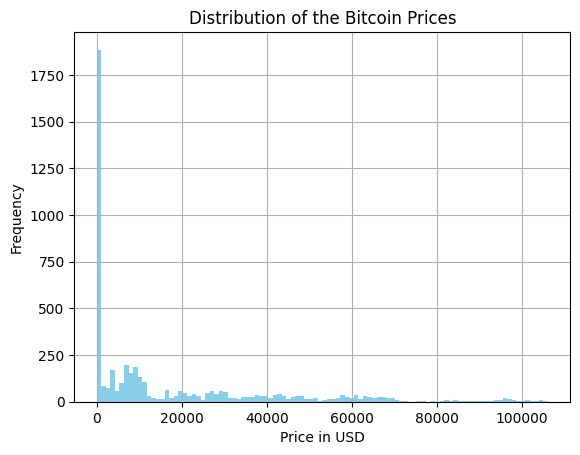

In [265]:
# understanding distribution of the data
plt.hist(btc_final_df['y'],bins=100,color='skyblue')
plt.title('Distribution of the Bitcoin Prices')
plt.xlabel('Price in USD')
plt.ylabel('Frequency')
plt.grid(True)

Text(0.5, 1.0, 'QQ Plot for the bitcoin Prices')

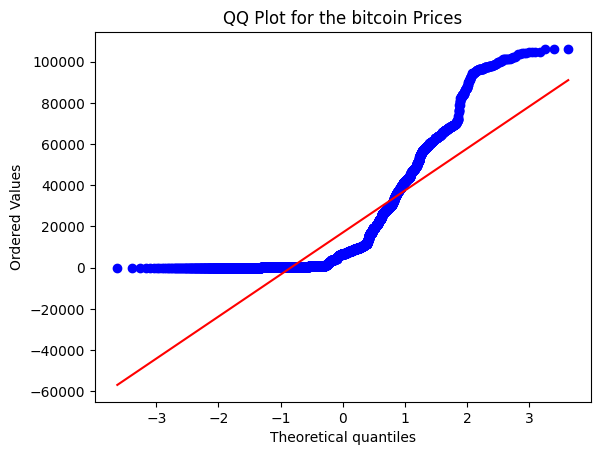

In [266]:
stats.probplot(btc_final_df['y'], dist="norm",plot=plt)
plt.title("QQ Plot for the bitcoin Prices")

The QQ plot shows that Bitcoin prices are **not normally distributed**, with heavy right skew and extreme outliers. This is typical for financial time series and justifies using models like **Prophet**, which don't assume normality.

In [267]:
#Performing Shapiro-Wilk normality test on the BTC closing prices 
stat,p=shapiro(btc_final_df['y'])
print("The p-value is:", p)
if p<0.05: 
    print("The data is not normally distributed rejects null hypothesis")
else:
    print("The data is normally distributed accepts null hypothersis")

The p-value is: 1.4966847871654827e-65
The data is not normally distributed rejects null hypothesis


We used the Shapiro-Wilk test to assess if Bitcoin prices are normally distributed. The extremely small p-value (1.4966487025416921e-65) indicates strong evidence against normality, which aligns with expectations given Bitcoin’s high volatility and skewed price behavior, which is typical in financial time series. Therefore, the data is normally distributed, and we reject the null hypothesis.

In [272]:
# Now, let's find the outliers
z_score = pd.DataFrame(zscore(['y']))
outliers = z_score[(z_score.abs() > 3)]
print(f"\nPotential outliers (z-score > 3): {len(outliers)}")
print(outliers[['ds', 'y']].head()) 

TypeError: the resolved dtypes are not compatible with add.reduce. Resolved (dtype('<U1'), dtype('<U1'), dtype('<U2'))

We identified **112 potential outliers** where Bitcoin's daily closing price deviated more than 3 standard deviations from the mean. These outliers, mainly in **late 2024**, reflect unusually high prices around **88K Dollars to 91K Dollars**.  They appear to represent a **real and sustained market surge**, not random noise — so we will **keep them** in the dataset. Facebook Prophet can handle such price movements as part of trend or changepoint modeling.

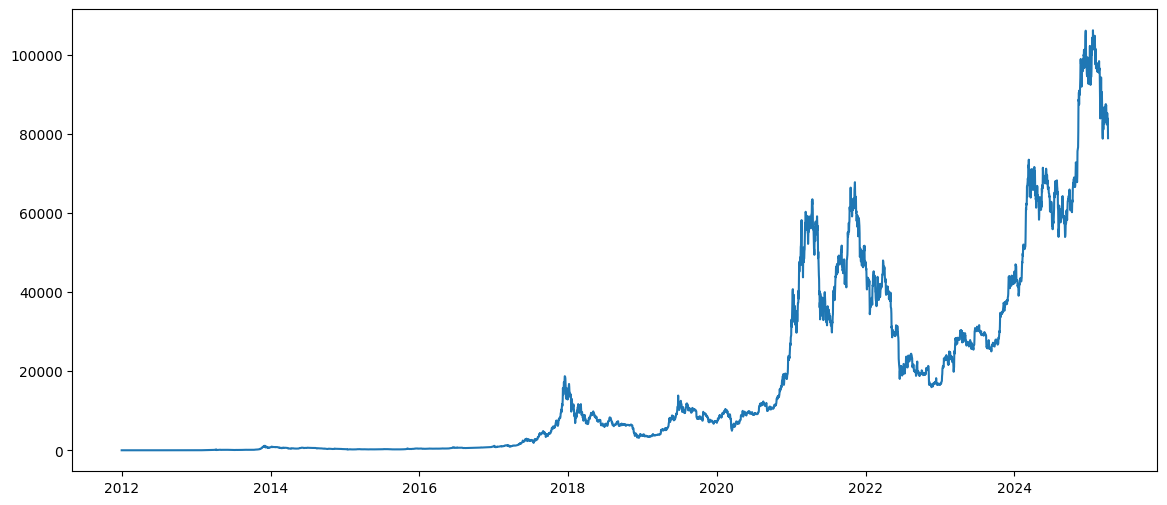

In [271]:
plt.figure(figsize=(14,6))
plt.plot(btc_final_df['ds'],btc_final_df['y'],label="BTC Price")
pkt.scatter()